(10, 48)
(10, 2)
arrived too


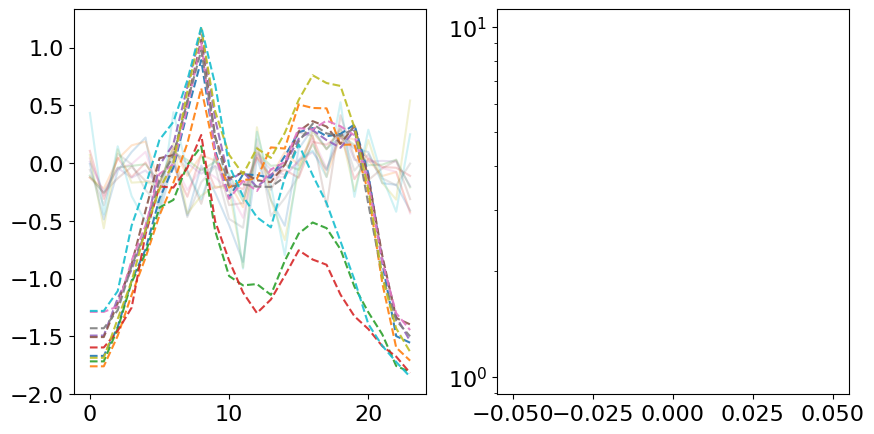

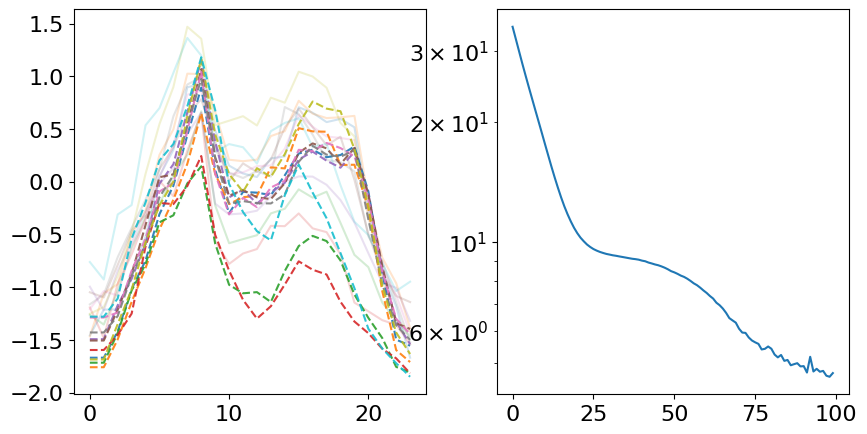

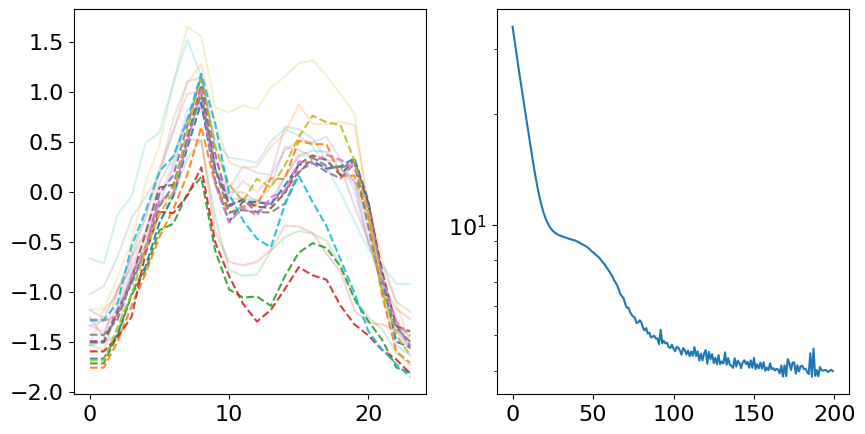

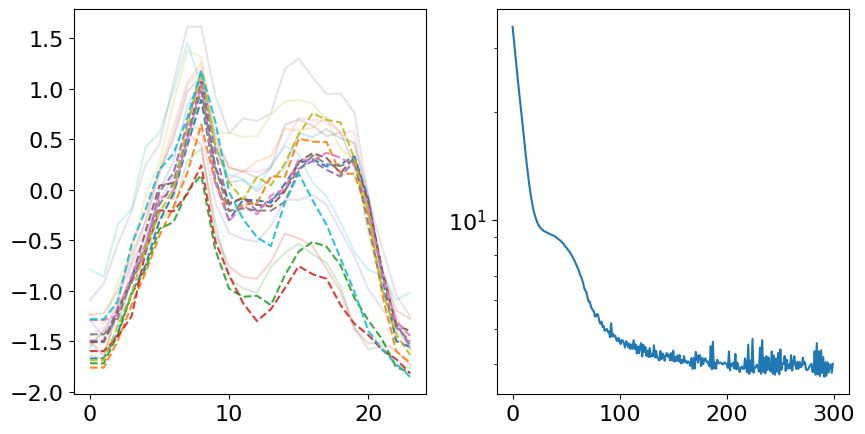

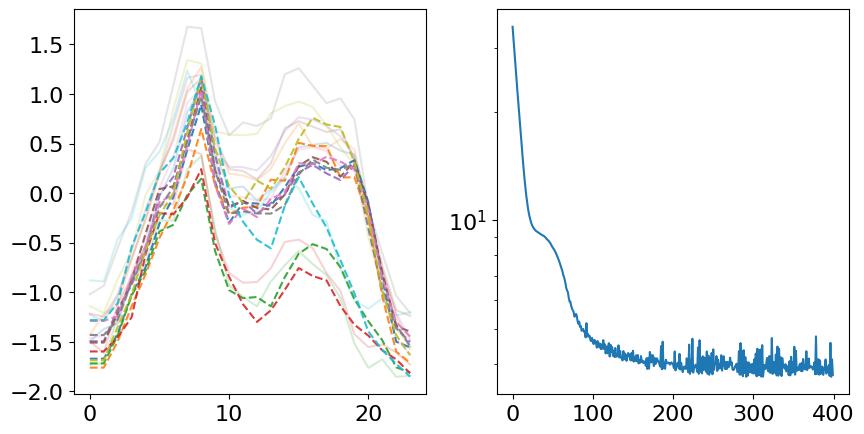

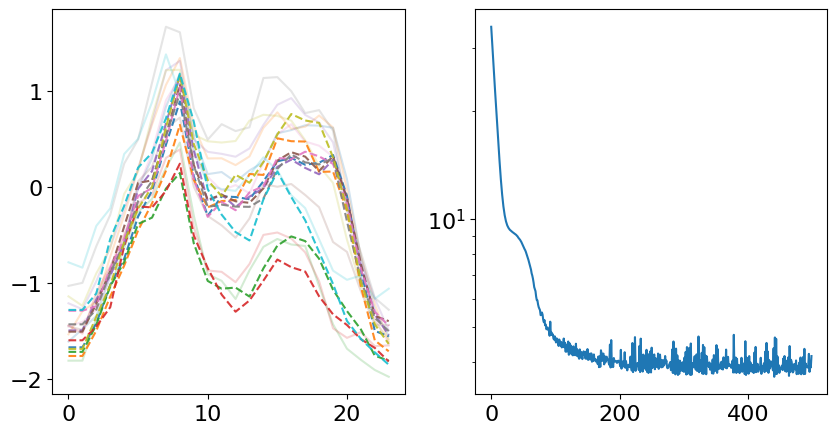

(0.0, 23.0)

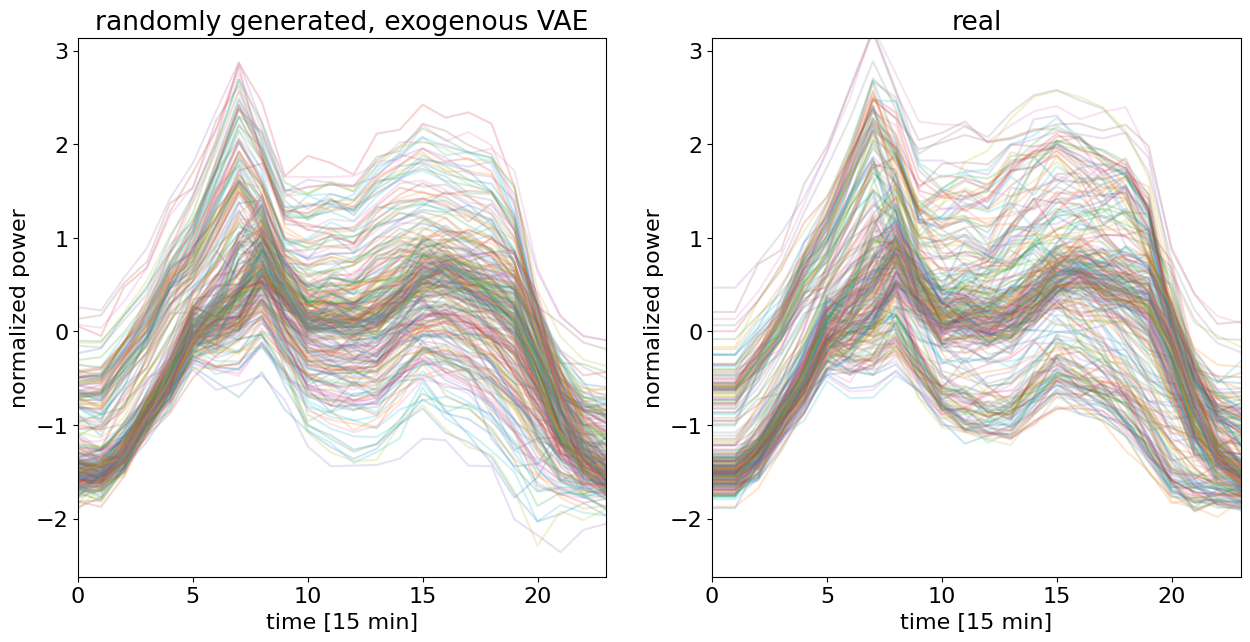

In [4]:
import time
import pandas as pd

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from flax import linen as nn
from jax import jit, grad, lax, random
import optax
import numpy as np

data = pd.read_pickle("https://zenodo.org/record/4549296/files/reduced_dataset.pk?download=1")
data_ts = data[['all']]
data_exogenous = data[['ghi_backwards','temperature']]


def add_lags(data, lags, name='all'):
  "adds lagged version of the signal with a given name to the data in the \
  DataFrame. Positive lags: shift forward (future), negative lags: shift\
  backward (past)."
  lagged_signal = pd.concat([data.copy()[[name]].shift(-l) for l in lags], axis=1)
  lagged_signal.columns=['{}_lag_{:+03d}'.format(name, l) for l in lags]
  lagged_dat = pd.concat([data, lagged_signal], axis=1)
  return lagged_dat.loc[~np.any(lagged_dat.isna(), axis=1)]

ts = add_lags(data_ts.resample('1h').mean(), -np.arange(23), name='all')
ts -= ts.mean()
ts /= ts.std()
ts = ts.loc[ts.index.hour==0]
ts.head()


exogenous = data_exogenous.loc[data_exogenous.index.isin(ts.index)]
exogenous = np.hstack([np.vstack(exogenous[k].values) for k in exogenous.keys()])
exogenous -= np.mean(exogenous,axis=0)
exogenous /= (1e-10+np.nanstd(exogenous,axis=0))
exogenous = pd.DataFrame(exogenous, index = ts.index)
exogenous.head()

INPUT_DIM = ts.shape[1]
OUTPUT_DIM = ts.shape[1]
LATENT_DIM = 2
EXOGEN_DIM = exogenous.shape[1]


def gaussian_kl(mu, sigmasq):
    """KL divergence from a diagonal Gaussian to the standard Gaussian."""
    return 0.5 * jnp.sum(1. + jnp.log(sigmasq) - mu ** 2. - sigmasq)


def gaussian_sample(rng, mu, sigmasq):
    """Sample a diagonal Gaussian."""
    n_mult = 1
    mus = jnp.vstack([mu for i in range(n_mult)])
    sigmas = jnp.vstack([jnp.sqrt(sigmasq) for i in range(n_mult)])
    randn = random.normal(rng, (mu.shape[0] * n_mult, mu.shape[1]))
    sample = mus + sigmas * randn

    return sample


def elbo(rng, params, ts, exogenous):
    """Monte Carlo estimate of the negative evidence lower bound."""
    enc_params, dec_params = params
    mu_z, sigmasq_z = encode(enc_params, ts)

    decode_input = jnp.hstack([gaussian_sample(rng, mu_z, sigmasq_z), exogenous])
    # decode_input =gaussian_sample(rng, mu_z, sigmasq_z)
    logits_x = decode(dec_params, decode_input)
    # ts = jnp.vstack([ts for i in range(20)])
    return jnp.sum((logits_x - ts) ** 2) - gaussian_kl(mu_z, sigmasq_z)


def predict(rng, params, ts, exogenous):
    """Monte Carlo estimate of the negative evidence lower bound."""
    enc_params, dec_params = params
    mu_z, sigmasq_z = encode(enc_params, ts)
    decode_input = jnp.hstack([gaussian_sample(rng, mu_z, sigmasq_z), exogenous])
    # decode_input = gaussian_sample(rng, mu_z, sigmasq_z)
    preds = decode(dec_params, decode_input)
    return preds


def ts_sample(rng, params, nrow, ncol, exogenous):
    """Sample ts from the generative model."""
    _, dec_params = params
    code_rng, img_rng = random.split(rng)
    print(exogenous.shape)
    print(random.normal(code_rng, (nrow * ncol, LATENT_DIM)).shape)
    decode_input = jnp.hstack([random.normal(code_rng, (nrow * ncol, LATENT_DIM)), exogenous])
    # decode_input =random.normal(code_rng, (nrow * ncol, LATENT_DIM))
    sampled_ts = decode(dec_params, decode_input)
    print('arrived too')

    return sampled_ts


DENSE_KWARGS = {
    "kernel_init": nn.initializers.glorot_normal(),
    "bias_init": nn.initializers.normal(),
}


class Encoder(nn.Module):
    latent_dim: int

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(128, **DENSE_KWARGS)(x)
        x = nn.relu(x)
        x = nn.Dense(128, **DENSE_KWARGS)(x)
        x = nn.relu(x)
        mu = nn.Dense(self.latent_dim, **DENSE_KWARGS)(x)
        sigmasq = nn.softplus(nn.Dense(self.latent_dim, **DENSE_KWARGS)(x))
        return mu, sigmasq


class Decoder(nn.Module):
    output_dim: int

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(128, **DENSE_KWARGS)(x)
        x = nn.relu(x)
        x = nn.Dense(128, **DENSE_KWARGS)(x)
        x = nn.relu(x)
        return nn.Dense(self.output_dim, **DENSE_KWARGS)(x)


encoder = Encoder(latent_dim=LATENT_DIM)
decoder = Decoder(output_dim=OUTPUT_DIM)


def encode(params, x):
    return encoder.apply({"params": params}, x)


def decode(params, x):
    return decoder.apply({"params": params}, x)

step_size = 4e-5
num_epochs = 600
batch_size = 10
nrow, ncol = 10, 1  # sampled image grid size


def tr_te_split(data, split_ratio=0.75):
  "divides data into training and test sets "
  n_tr = int(len(data)*split_ratio)
  return data.iloc[:n_tr, :].values, data.iloc[n_tr:, :].values

test_rng = random.PRNGKey(1)  # fixed prng key for evaluation
train_ts, test_ts  = tr_te_split(ts)
train_ex, test_ex  = tr_te_split(exogenous)

num_complete_batches, leftover = divmod(train_ts.shape[0], batch_size)
num_batches = num_complete_batches + bool(leftover)

enc_init_rng, dec_init_rng = random.split(random.PRNGKey(2))
init_encoder_params = encoder.init(enc_init_rng, jnp.ones((batch_size, INPUT_DIM)))["params"]
init_decoder_params = decoder.init(dec_init_rng, jnp.ones((batch_size, LATENT_DIM+EXOGEN_DIM)))["params"]
init_params = init_encoder_params, init_decoder_params

optimizer = optax.adam(step_size)

train_ts = jax.device_put(train_ts)
test_ts = jax.device_put(test_ts)
train_ex = jax.device_put(train_ex)
test_ex = jax.device_put(test_ex)


def binarize_batch(rng, i, ts, exogenous):
  i = i % num_batches
  batch = lax.dynamic_slice_in_dim(ts, i * batch_size, batch_size)
  batch_ex = lax.dynamic_slice_in_dim(exogenous, i * batch_size, batch_size)
  return batch, batch_ex


@jit
def run_epoch(rng, params, opt_state, ts, exogenous):
  def body_fun(i, state):
    params, opt_state = state
    elbo_rng, data_rng = random.split(random.fold_in(rng, i))
    batch, batch_ex = binarize_batch(data_rng, i, ts, exogenous)
    loss = lambda params: elbo(elbo_rng, params, batch, batch_ex) / batch_size
    g = grad(loss)(params)
    updates, opt_state = optimizer.update(g, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state
  return lax.fori_loop(0, num_batches, body_fun, (params, opt_state))


@jit
def evaluate(params, ts, exogenous):
  elbo_rng, data_rng, image_rng = random.split(test_rng, 3)
  test_elbo = elbo(elbo_rng, params, ts, exogenous) / ts.shape[0]
  sampled_ts = ts_sample(image_rng, params, nrow, ncol, exogenous[:(nrow+ncol-1),:])
  return test_elbo, sampled_ts


params = init_params
opt_state = optimizer.init(params)
loss_history = np.zeros(num_epochs)
for epoch in range(num_epochs):
  tic = time.time()
  params, opt_state = run_epoch(random.PRNGKey(epoch), params, opt_state, train_ts, train_ex)
  test_elbo, sampled_ts = evaluate(params, test_ts, test_ex)
  loss_history[epoch] = test_elbo
  preds = predict(random.PRNGKey(epoch), params, test_ts[:10,:], test_ex[:10,:])
  if epoch%100==0:
    fig, ax = plt.subplots(1,2,figsize=(10,5))
    ax[0].plot(preds.T, alpha=0.2)
    ax[0].plot(test_ts[:10,:].T, alpha=0.9, linestyle= '--')
    ax[1].plot(loss_history[:epoch])
    ax[1].semilogy()
    plt.show()

sampled_ts = decode(params[1], jnp.hstack([random.normal(random.PRNGKey(0), (len(train_ts), LATENT_DIM)), train_ex]))
fig, ax = plt.subplots(1, 2, figsize=(15,7))
plt.rcParams.update({'font.size': 16})

ax[0].plot(sampled_ts.T, alpha=0.2)
ax[1].plot(train_ts.T, alpha=0.2)
ax[1].set_ylim(ax[0].get_ylim())
ax[0].set_title('randomly generated, exogenous VAE')
ax[1].set_title('real')
ax[0].set_xlabel('time [15 min]')
ax[1].set_xlabel('time [15 min]')
ax[0].set_ylabel('normalized power')
ax[1].set_ylabel('normalized power');
ax[0].set_xlim(0,23)
ax[1].set_xlim(0,23)